## 1. Evaluation

### 1.1 Evaluate each model on bdd_val

In [23]:
from ultralytics import YOLO

In [26]:
models = ['baseline3', 'bdd_finetune', 'fg_preserved', 'bg_preserved']

def eval_on_bdd(model_name):
    model = YOLO(f"../runs/detect/{model_name}/weights/best.pt")

    metrics = model.val(
        data=r"D:\UCSD_courses\ECE285\project\yolo\config\bdd_finetune.yaml",
        split="val",
        imgsz=640,
        batch=16,
        workers=0,
        name=f"{model_name}_on_bdd_val"
    )

    print("mAP50-95:", metrics.box.map)
    print("mAP50:", metrics.box.map50)
    print("Precision:", metrics.box.mp)
    print("Recall:", metrics.box.mr)
    return {
        "mAP50-95":metrics.box.map,
        "mAP50":metrics.box.map50,
        "Precision": metrics.box.mp,
        "Recall":metrics.box.mr
    }

bdd_results = {}
for model in models:
    metrics = eval_on_bdd(model)
    bdd_results[model] = metrics

Ultralytics 8.4.19  Python-3.10.19 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3070, 8192MiB)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 540.099.6 MB/s, size: 67.2 KB)
val: Scanning D:\UCSD_courses\ECE285\project\data\bdd_yolo\labels\val.cache... 257 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 257/257  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 17/17 7.5it/s 2.3s0.1s
                   all        257        257      0.457      0.154      0.181      0.126
Speed: 0.3ms preprocess, 2.0ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to D:\UCSD_courses\ECE285\project\yolo\runs\detect\baseline3_on_bdd_val
mAP50-95: 0.12601276932686234
mAP50: 0.18149710763942367
Precision: 0.45736202135394677
Recall: 0.15415039686813725
Ultralytics 8.4.19  Python-3.10.19 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3070, 8192

### 1.2 Visualization

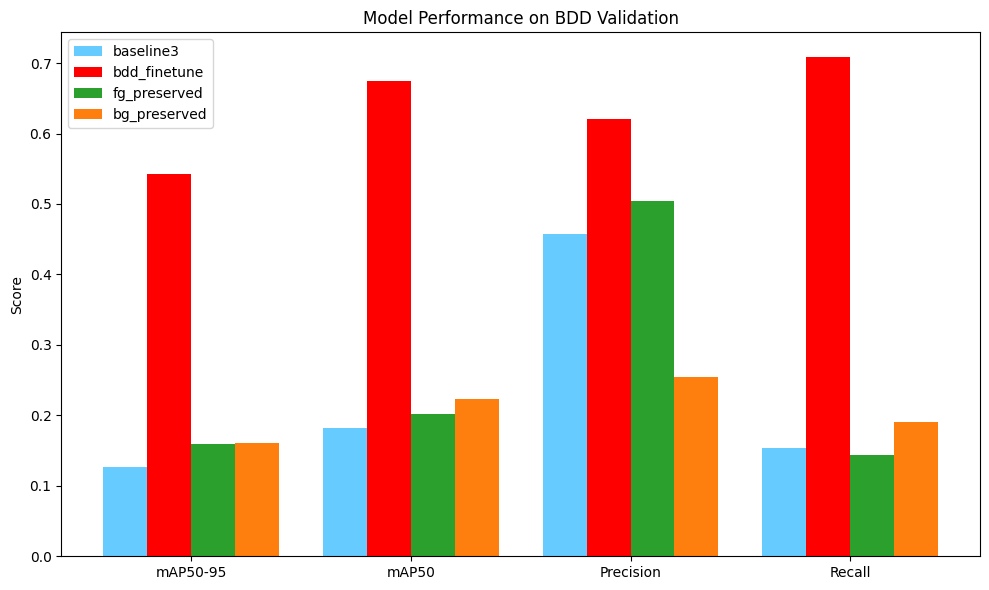

In [31]:
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline
model_colors = {
    "baseline3": "#66ccff",      # blue
    "bg_preserved": "#ff7f0e",  # orange
    "fg_preserved": "#2ca02c",  # green
    "bdd_finetune": "#ff0000"     # red
}
metrics = ["mAP50-95", "mAP50", "Precision", "Recall"]
models = list(bdd_results.keys())

values = np.array([[bdd_results[m][metric] for metric in metrics] for m in models])

x = np.arange(len(metrics))
width = 0.2

plt.figure(figsize=(10,6))

for i, model in enumerate(models):
    plt.bar(x + i*width, values[i], width, label=model, color=model_colors[model])

plt.xticks(x + width*1.5, metrics)
plt.ylabel("Score")
plt.title("Model Performance on BDD Validation")
plt.legend()

plt.tight_layout()
plt.show()

### 1.3 Evaluate each model on clean_val

In [28]:
def eval_on_clean(model_name):
    model = YOLO(f"../runs/detect/{model_name}/weights/best.pt")

    metrics = model.val(
        data=r"D:\UCSD_courses\ECE285\project\yolo\config\baseline.yaml",
        split="val",
        imgsz=640,
        batch=16,
        workers=0,
        name=f"{model_name}_on_clean_val"
    )

    print("mAP50-95:", metrics.box.map)
    print("mAP50:", metrics.box.map50)
    print("Precision:", metrics.box.mp)
    print("Recall:", metrics.box.mr)
    return {
        "mAP50-95":metrics.box.map,
        "mAP50":metrics.box.map50,
        "Precision": metrics.box.mp,
        "Recall":metrics.box.mr
    }

clean_results = {}
for model in models:
    metrics = eval_on_clean(model)
    clean_results[model] = metrics

Ultralytics 8.4.19  Python-3.10.19 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3070, 8192MiB)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access  (ping: 2.14.3 ms, read: 17.618.5 MB/s, size: 75.6 KB)
val: Scanning D:\UCSD_courses\ECE285\project\data\cleaned_yolo\labels\val.cache... 408 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 408/408  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 26/26 4.1it/s 6.3s0.2s
                   all        408        408      0.995          1      0.994      0.962
Speed: 0.3ms preprocess, 3.3ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to D:\UCSD_courses\ECE285\project\yolo\runs\detect\baseline3_on_clean_val
mAP50-95: 0.9623596092501933
mAP50: 0.9943627450980391
Precision: 0.9948475967294442
Recall: 1.0
Ultralytics 8.4.19  Python-3.10.19 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3070, 8192MiB)
YOLO11n s

### 1.4 Visualization

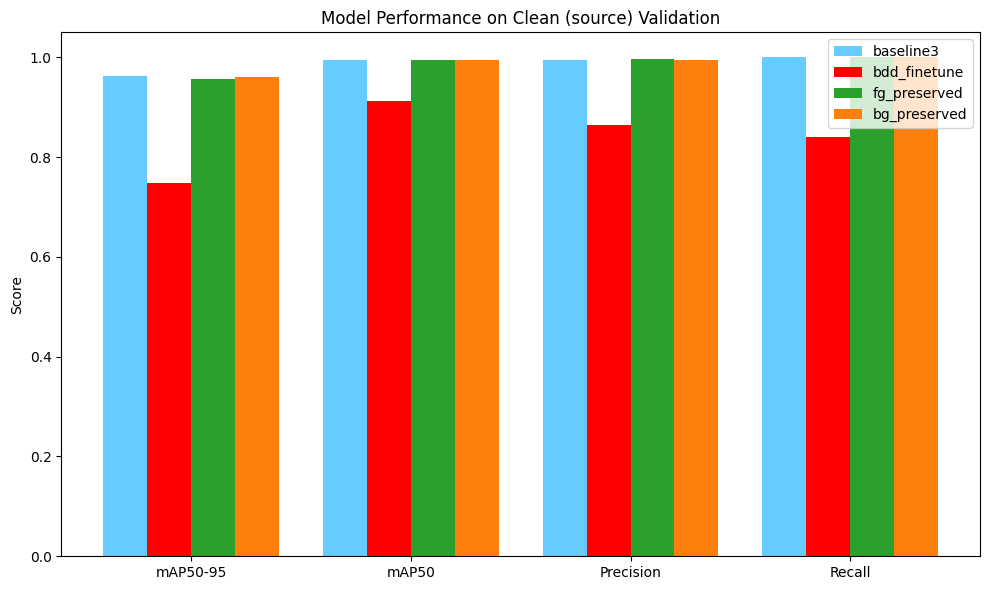

In [32]:
models = list(clean_results.keys())

values = np.array([[clean_results[m][metric] for metric in metrics] for m in models])

x = np.arange(len(metrics))
width = 0.2

plt.figure(figsize=(10,6))

for i, model in enumerate(models):
    plt.bar(x + i*width, values[i], width, label=model, color=model_colors[model])

plt.xticks(x + width*1.5, metrics)
plt.ylabel("Score")
plt.title("Model Performance on Clean (source) Validation")
plt.legend()

plt.tight_layout()
plt.show()